# Exploratory Data Analysis

This notebook explores the cleaned transaction data to understand retention trends.

We divide this exploration into two phases:
1. Inputs: Understanding the shape of the user base, payment gateways and plan behaviours
2. Outcome: Understanding censoring, event distribution and cohort retention

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

## Explore the Inputs

### 1.1 Load the survival table

In [ ]:

df = pd.read_csv("../data/survival_table.csv", parse_dates=["start_date", "endpoint_date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2417562 entries, 0 to 2417561
Data columns (total 11 columns):
 #   Column              Dtype         
---  ------              -----         
 0   msno                object        
 1   start_date          datetime64[ns]
 2   endpoint_date       datetime64[ns]
 3   duration_days       int64         
 4   event               int64         
 5   payment_method_id   int64         
 6   payment_plan_days   int64         
 7   plan_list_price     int64         
 8   actual_amount_paid  int64         
 9   is_auto_renew       int64         
 10  is_cancel           int64         
dtypes: datetime64[ns](2), int64(8), object(1)
memory usage: 202.9+ MB


### 1.2 Acquisition Volume Over Time
How many users joined the platform each month?

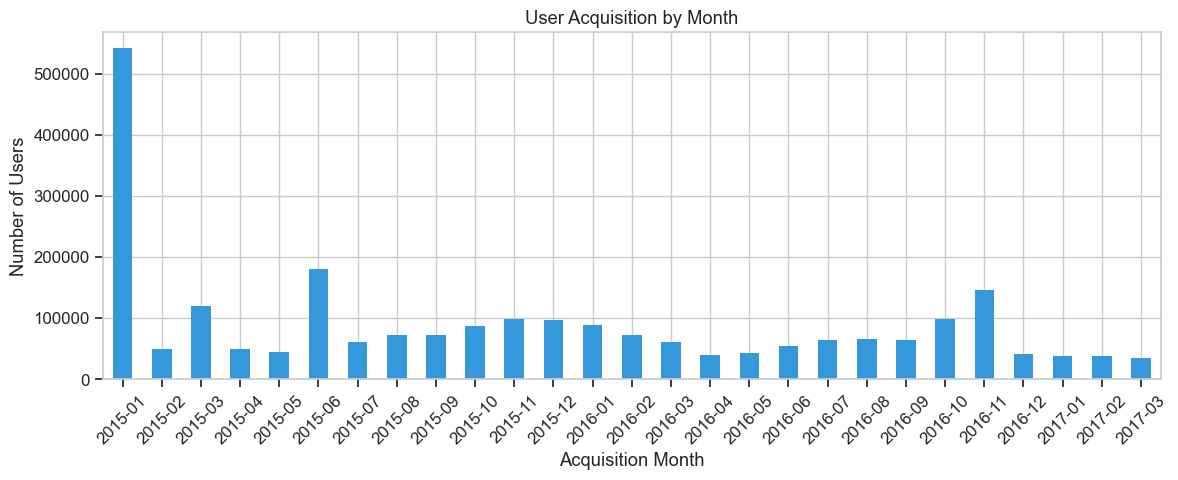

In [6]:
df['acq_month'] = df['start_date'].dt.to_period('M')
acq_counts = df.groupby('acq_month').size()

plt.figure(figsize=(12, 5))
acq_counts.plot(kind='bar', color='#3498db')
plt.title("User Acquisition by Month")
plt.xlabel("Acquisition Month")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

There was a massive influx of over 500,000 users joining in January 2015. Because this bulk of users joined so early in the observation window, they benefited from a much longer exposure period (over two years) before the end of the observation window. This enables the survival models to observe mature, long-term retention behaviours rather than being dominated by short-term data.

### 1.3 Univariate Covariates
Let's explore the distribution of our core features.

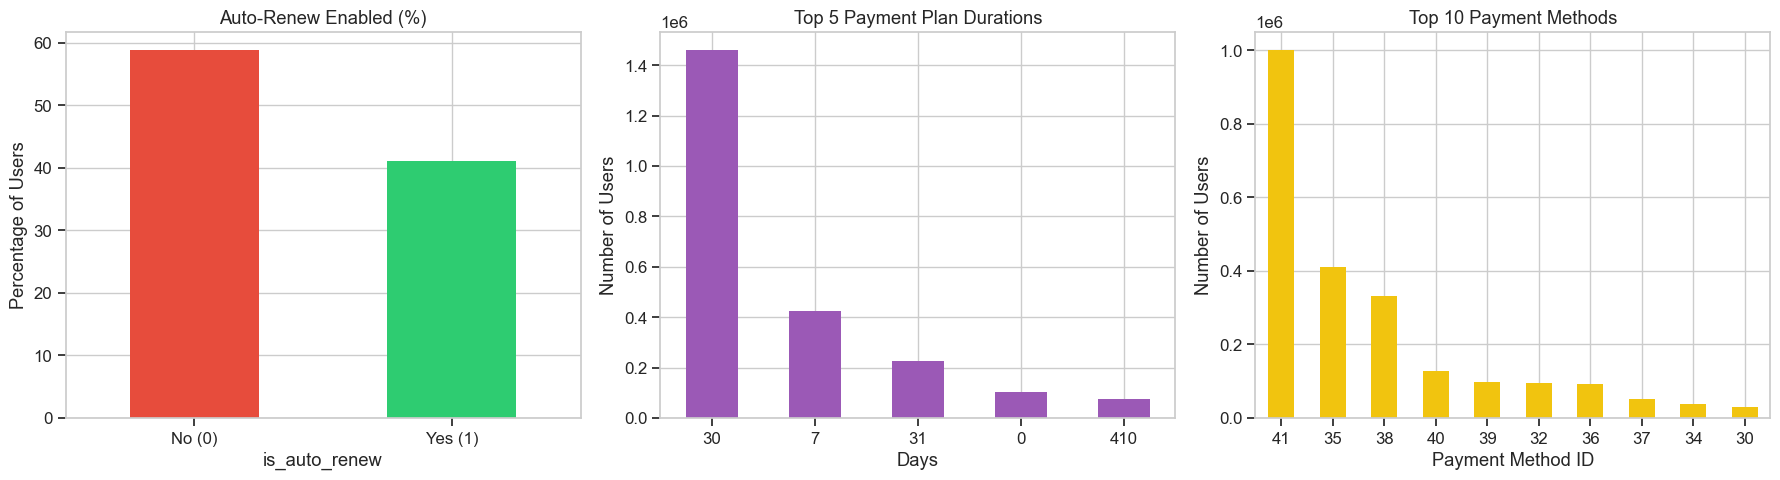

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Auto-renew
auto_counts = df['is_auto_renew'].value_counts(normalize=True) * 100
auto_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Auto-Renew Enabled (%)')
axes[0].set_ylabel('Percentage of Users')
axes[0].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)

# Plan Days
plan_counts = df['payment_plan_days'].value_counts().head(5)
plan_counts.plot(kind='bar', ax=axes[1], color='#9b59b6')
axes[1].set_title('Top 5 Payment Plan Durations')
axes[1].set_ylabel('Number of Users')
axes[1].set_xlabel('Days')
axes[1].tick_params(axis='x', rotation=0)

# Payment Methods
pm_counts = df['payment_method_id'].value_counts().head(10)
pm_counts.plot(kind='bar', ax=axes[2], color='#f1c40f')
axes[2].set_title('Top 10 Payment Methods')
axes[2].set_ylabel('Number of Users')
axes[2].set_xlabel('Payment Method ID')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

*   **Auto-Renew:** The majority of users (~60%) do not have auto-renew enabled. Auto-renew as a critical behavioural variable that we must evaluate in our survival models to measure its impact on churn.
*   **Plan Durations:** The platform's revenue model is overwhelmingly anchored on standard monthly (30-day) billing cycles, with 7-day trials/weekly plans acting as a distant secondary driver.
*   **Payment Methods:** The payment gateway is heavily concentrated. Method 41 alone handles nearly half the user base, while a long tail of smaller gateways handles the rest.


### 1.4 Pricing & Discounting
Does `actual_amount_paid` differ from `plan_list_price`?

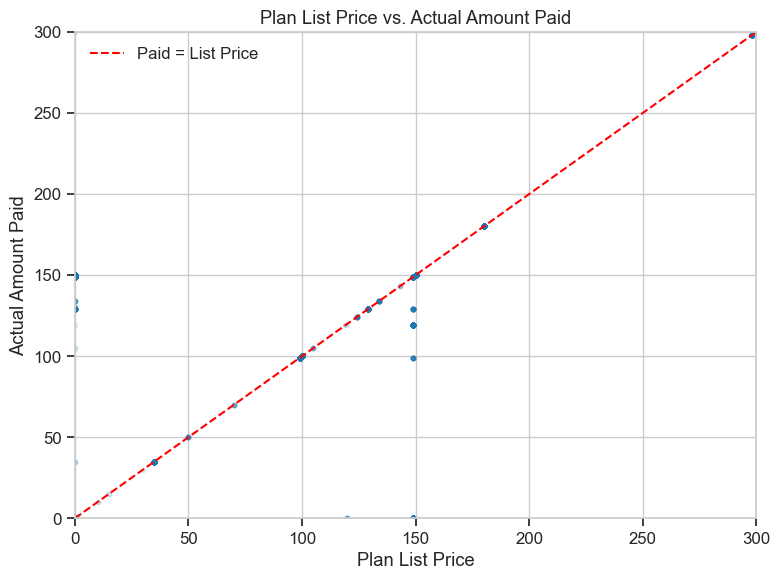

In [11]:
# Downsample for faster scatter plotting
sample_df = df.sample(n=100000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample_df['plan_list_price'], sample_df['actual_amount_paid'], alpha=0.1, s=10)
plt.plot([0, 2000], [0, 2000], color='red', linestyle='--', label='Paid = List Price')
plt.title("Plan List Price vs. Actual Amount Paid")
plt.xlabel("Plan List Price")
plt.ylabel("Actual Amount Paid")
plt.xlim(0, 300)
plt.ylim(0, 300)
plt.legend()
plt.tight_layout()
plt.show()

The majority of transactions fall exactly on the red line, meaning users generally pay the stated list price. However, we see two interesting deviations:
1. **Discounting & Free Trials:** Points falling below the red line (e.g., a list price of 149 but an actual paid amount of 99 or 0) could indicate promotional discounts, partial refunds or free trials.
2. **Anomalies:** Points clustered on the y-axis (where the list price is 0, but the user paid a positive amount) could represent data anomalies or custom/legacy billing events. 

These deviations show that `plan_list_price` and `actual_amount_paid` are not perfectly collinear, meaning both variables contain unique behavioural signals.


### 1.5 Bivariate Relationships
Here we explore covariate overlap by binning the plan durations into 5 groups and checking how heavily auto-renewal and payment methods vary across them.

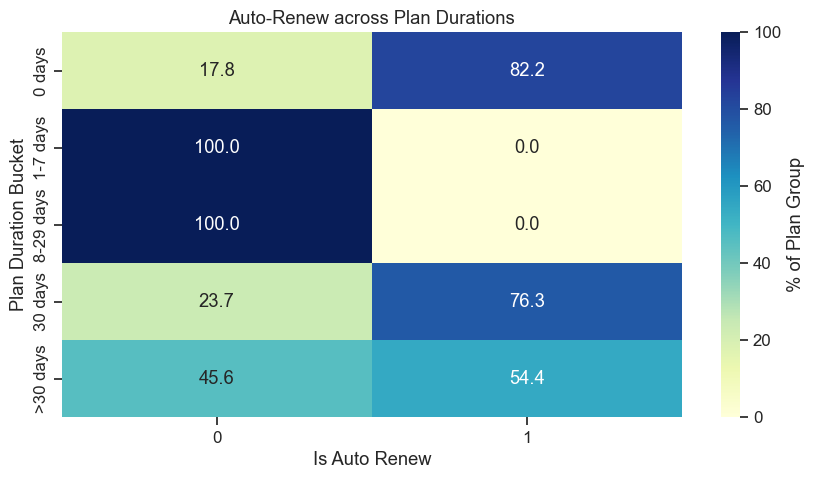

In [19]:
# Bin plan days
conditions = [
    df["payment_plan_days"] == 0,
    df["payment_plan_days"].between(1, 7),
    df["payment_plan_days"].between(8, 29),
    df["payment_plan_days"] == 30,
    df["payment_plan_days"] > 30
]
labels = ["0 days", "1-7 days", "8-29 days", "30 days", ">30 days"]
df["plan_group"] = np.select(conditions, labels, default="Other")

# Auto-Renew by Plan Group
plt.figure(figsize=(10, 5))
crosstab_auto = pd.crosstab(df['plan_group'], df['is_auto_renew'], normalize='index') * 100
crosstab_auto = crosstab_auto.loc[labels] # order correctly
sns.heatmap(crosstab_auto, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '% of Plan Group'})
plt.title("Auto-Renew across Plan Durations")
plt.ylabel("Plan Duration Bucket")
plt.xlabel("Is Auto Renew")
plt.show()

This heatmap reveals strong structural dependencies between payment plan lengths and auto-renewal behaviours:
1. **Perfect Separation:** The `1-7 days` and `8-29 days` plan buckets have exactly 0% auto-renew penetration. This suggests these short-term or trial plans are structurally hardcoded as manual-renewal only.
2. **The Recurring Driver:** The core `30 days` plan boasts a strong 76% auto-renew rate, acting as the primary engine for recurring revenue.
3. **Modeling Implications:** Because auto-renew is perfectly correlated (100% absent) in certain plan groups, putting both variables into a predictive model raw will cause collinearity issues and inflated standard errors. This suggests stratifying our survival models by plan duration to isolate the true effect of auto-renewal.

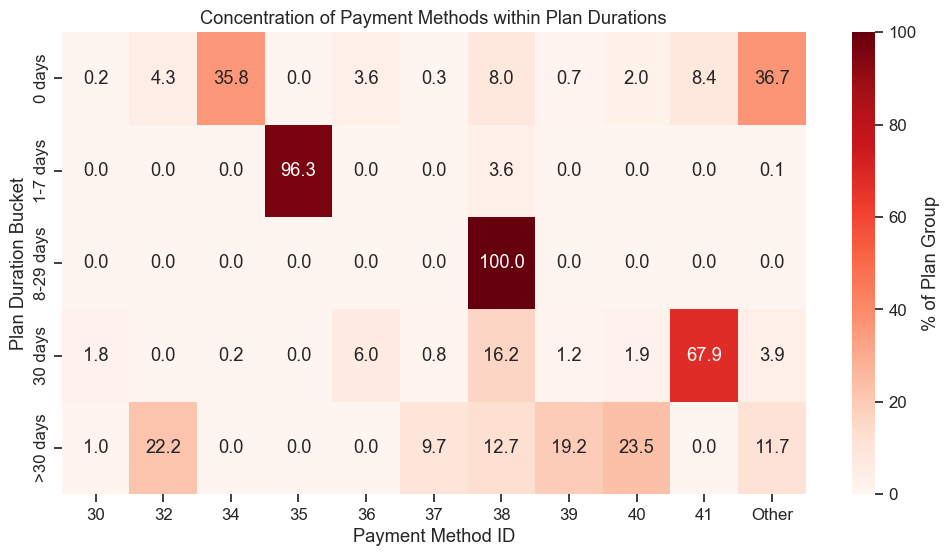

In [13]:
# Payment Method by Plan Group
top_methods = df["payment_method_id"].value_counts().nlargest(10).index
df["payment_method_grouped"] = df["payment_method_id"].apply(lambda x: str(x) if x in top_methods else "Other")

plt.figure(figsize=(12, 6))
crosstab_pm = pd.crosstab(df['plan_group'], df['payment_method_grouped'], normalize='index') * 100
crosstab_pm = crosstab_pm.loc[labels]
sns.heatmap(crosstab_pm, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': '% of Plan Group'})
plt.title("Concentration of Payment Methods within Plan Durations")
plt.ylabel("Plan Duration Bucket")
plt.xlabel("Payment Method ID")
plt.show()

1. **Structural Monopolies:** Payment methods are not randomly distributed. Method `35` holds a near-monopoly (96.3%) on 1-7 day plans, and Method `38` holds a literal 100% monopoly on 8-29 day plans. 
2. **The 30-Day Engine:** Method `41`, which we know is the most popular gateway overall, derives its massive volume almost exclusively from the core 30-day plan (67.9%). Interestingly, it handles exactly 0% of the long-term (>30 day) subscriptions. 
3. **Long-Term Gateways:** Subscriptions longer than 30 days rely on a completely different cluster of payment methods (`32`, `39`, `40`), suggesting these gateways are specialised for quarterly or annual billing.
4. **Modeling Implications:** Because certain payment methods act as near-perfect predictors of plan duration (e.g., Method 38 = 8-29 day plan), entering both variables raw into a Cox model will cause multicollinearity. This mandates stratifying the baseline hazard by plan duration in survival modelling.


## Explore the Outcome

### 2.1 Event vs. Censoring Structure
Survival analysis handles data where the event (churn) hasn't happened yet for everyone. Users who haven't churned by the end of our observation window (March 31, 2017) are marked as **censored** (event=0).

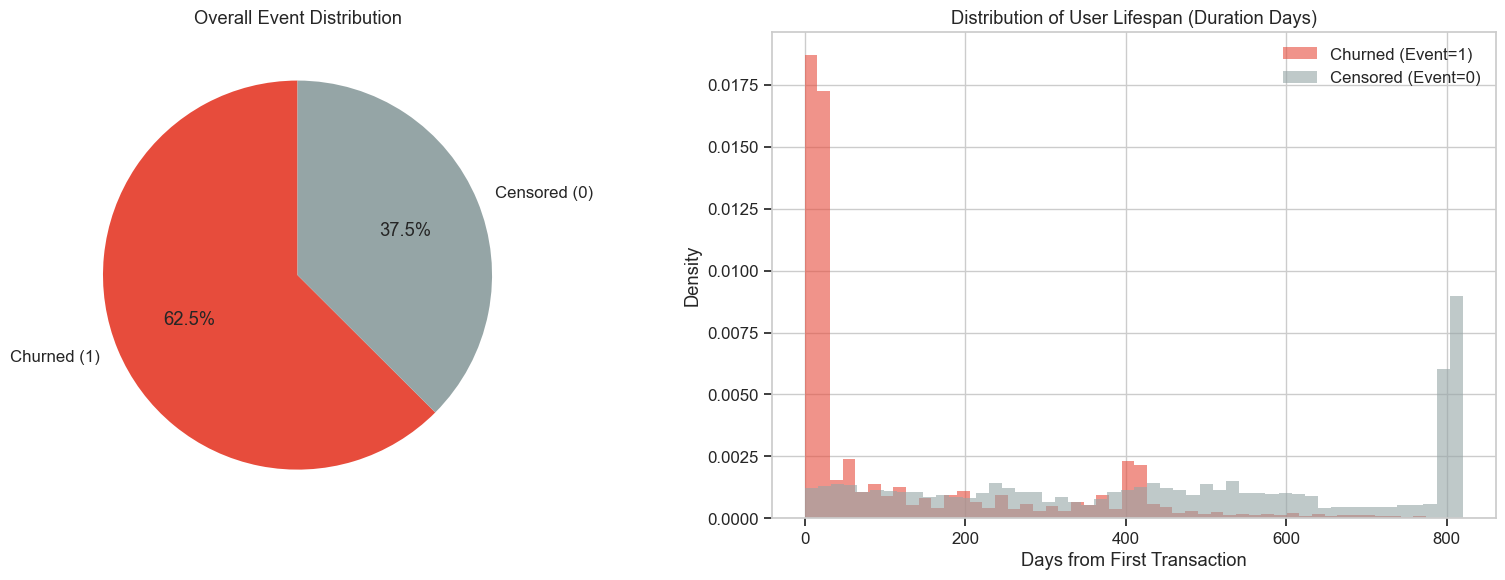

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall pie
event_counts = df['event'].value_counts()
axes[0].pie(event_counts, labels=['Churned (1)', 'Censored (0)'], autopct='%1.1f%%', colors=['#e74c3c', '#95a5a6'], startangle=90)
axes[0].set_title('Overall Event Distribution')

# Duration distribution overlaid
axes[1].hist(df[df['event']==1]['duration_days'], bins=50, alpha=0.6, color='#e74c3c', label='Churned (Event=1)', density=True)
axes[1].hist(df[df['event']==0]['duration_days'], bins=50, alpha=0.6, color='#95a5a6', label='Censored (Event=0)', density=True)
axes[1].set_title('Distribution of User Lifespan (Duration Days)')
axes[1].set_xlabel('Days from First Transaction')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

1. **The Early Churn Cliff:** The orange distribution (Churned users) shows a massive density spike in the first 0-30 days. This is classic subscription behaviour where a huge portion of the user base drops off immediately after their first transaction or trial period expires.
2. **Administrative Censoring:** The grey distribution (Censored users) reveals a massive, unnatural spike at the ~800-day mark. This is *not* random noise. Because our observation window is fixed (ending March 31, 2017), users who joined during the massive January 2015 acquisition spike and survived the entire duration will structurally max out at ~800 days. 
3. **Why this matters:** This chart proves our censoring is "administrative" (driven by the study's end date) rather than "informative" (driven by unobserved, random dropouts), satisfying the core assumption required to use Kaplan-Meier estimators and Cox Proportional Hazards models later on.


### 2.2 Cohort Retention Matrix - Acquisition Cohorts
Finally, we visualize a classic business metric, the Monthly Retention Matrix. 

We define a user as "retained in Month M" if their `duration_days` is greater than or equal to `M * 30`. 

*Caveat:* Unlike a Kaplan-Meier estimator, a simple retention matrix does not formally adjust for right-censoring. If a cohort hits the edge of our observation window at Month 6, months 7+ will simply appear empty. We use this matrix for high-level business reporting, and reserve censoring-adjusted time-to-event visuals (KM plots) for the survival modelling.

In [17]:
# Filter to cohorts within observation window
cohort_df = df[df['start_date'] >= '2015-01-01'].copy()
cohort_df['acq_month'] = cohort_df['start_date'].dt.to_period('M')

# Max months to track
max_months = 24

# Create a dataframe of all users and their max active month
cohort_df['max_active_month'] = cohort_df['duration_days'] // 30

# Build a matrix where rows are acq_month, cols are month_0 to month_N
retention_matrix = pd.DataFrame(index=sorted(cohort_df['acq_month'].unique()), columns=range(max_months + 1))

for cohort in retention_matrix.index:
    cohort_users = cohort_df[cohort_df['acq_month'] == cohort]
    total_users = len(cohort_users)
    
    for m in range(max_months + 1):
        # A user is active in month 'm' if their max_active_month >= m
        active_users = len(cohort_users[cohort_users['max_active_month'] >= m])
        
        # If a cohort is censored, their max_active_month just stops, leading to 0s
        if active_users == 0 and m > 0:
            retention_matrix.loc[cohort, m] = np.nan # Unobserved
        else:
            retention_matrix.loc[cohort, m] = active_users / total_users

retention_matrix = retention_matrix.astype(float)

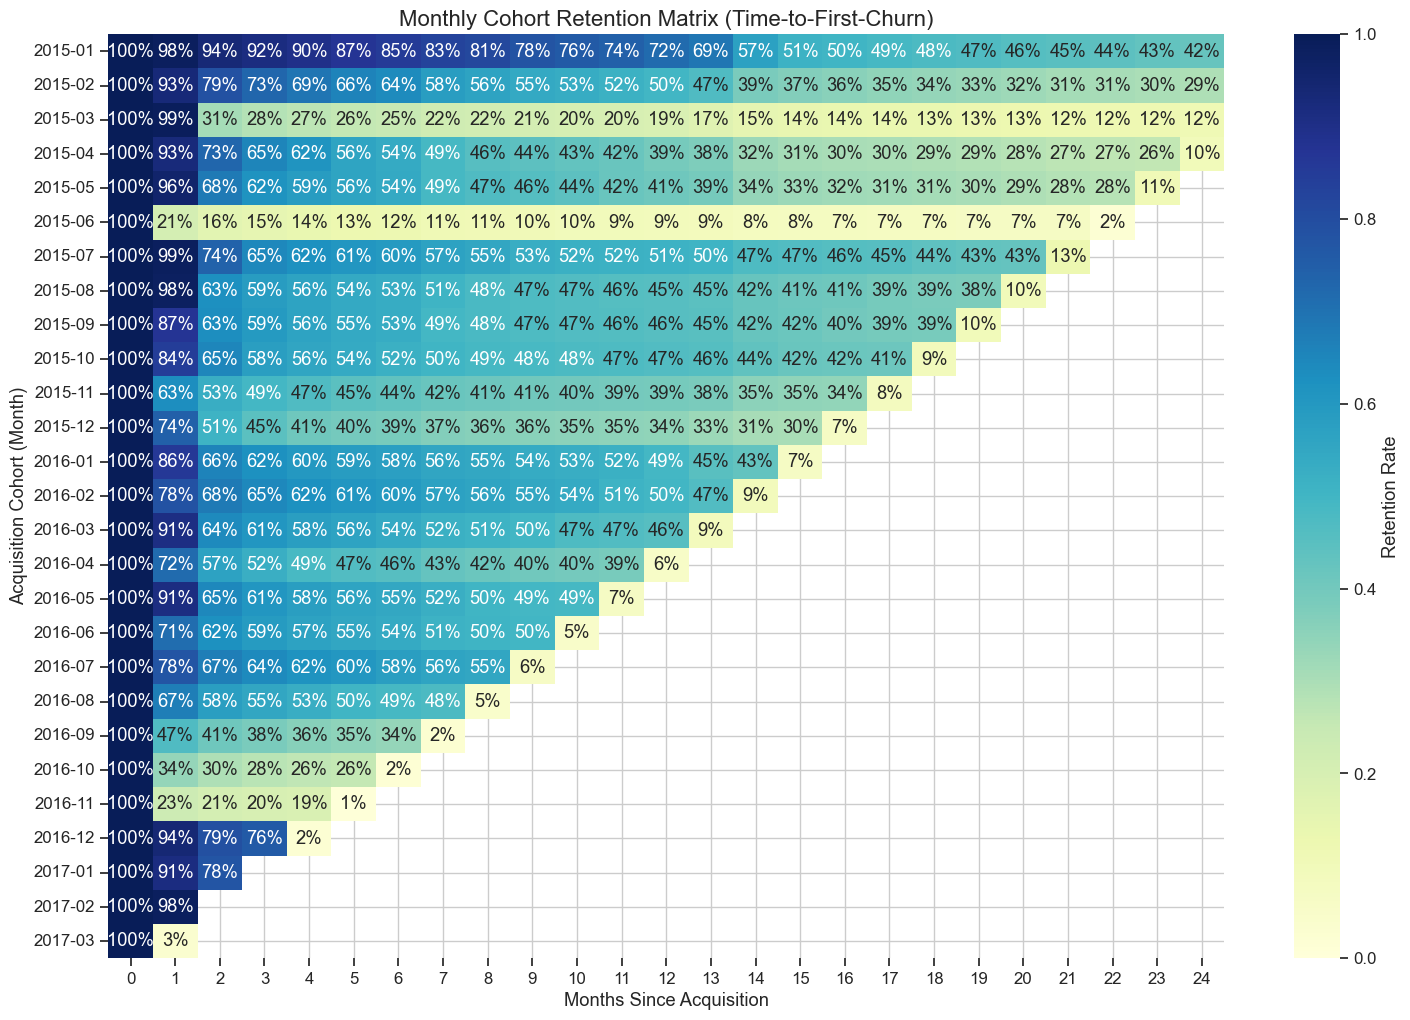

In [18]:
plt.figure(figsize=(18, 12))
sns.heatmap(
    retention_matrix, 
    annot=True, 
    fmt=".0%", 
    cmap="YlGnBu", 
    vmin=0.0, 
    vmax=1.0,
    cbar_kws={'label': 'Retention Rate'}
)
plt.title("Monthly Cohort Retention Matrix (Time-to-First-Churn)", fontsize=16)
plt.ylabel("Acquisition Cohort (Month)")
plt.xlabel("Months Since Acquisition")
plt.show()

This 24-month retention matrix reveals extreme variance in the quality of acquisition cohorts:
1. **Cohort 2015-01:** The massive 500k+ user spike from January 2015 demonstrates incredibly strong loyalty. It retains 98% of users into Month 1, and 42% of users are still active a full two years later (Month 24).
2. **Acquisition Quality:** Other cohorts exhibit huge, immediate cliffs. For example, the `2015-06`, `2016-10`, and `2016-11` cohorts drop to 20-30% retention almost instantly in Month 1. This highly erratic behavior suggests these cohorts were likely driven by aggressive short-term marketing campaigns, 30-day free trials or low-intent user acquisition strategies.
3. **Censoring":** The empty white space stepping up from the bottom right perfectly illustrates how recent cohorts run out of observation time. A user who joined in January 2017 mathematically cannot have more than 3 months of observed retention before the March 2017 cutoff.
